## Project Structure

This codebase is organized into the following sections:

### 1. Exploratory Data Analysis (EDA)
- Distribution plots to understand feature distributions  
- Correlation plots to identify relationships between variables  
- Outlier identification to detect extreme values  

### 2. Pre-processing
- Z-score scaling for features with approximately normal distributions  
- Log(1 + x) transformation for highly skewed features with significant outliers  
- Robust scaling for columns sensitive to extreme values  
- Dimensionality Reduction with **PCA**

### 3. Clustering
- Cluster fitting using multiple clustering algorithms  
- Cluster analysis and interpretation of resulting groups  

### 4. Final Remarks
- Summary of findings  
- Key observations and limitations  
- Recommendations for future work  


Imports

In [294]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import seaborn as sns
import math
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler
os.getcwd()

'c:\\Users\\OMNI BOOK\\OneDrive - Lancaster University\\MichaelMas Term\\Machine Learning- SCC451\\Final Project\\Task 1- Clustering'

Some helper functions that we use frequently so that it doesnt get congested later

In [295]:
#plotting a histogram
def plot_histograms(df):
    num_cols = df.select_dtypes(include='number').columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, num_cols):
        ax.hist(df[col])
        ax.set_title(col)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    for ax in axes[len(num_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

#Plotting a box plot
def plot_boxplots(df):
    num_cols = df.select_dtypes(include='number').columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, num_cols):
        ax.boxplot(df[col], vert=True)
        ax.set_title(col)

    for ax in axes[len(num_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(df, method='pearson'):
    corr = df.select_dtypes(include='number').corr(method=method)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        square=True,
        cbar_kws={'shrink': 0.8},
        annot_kws={"size": 8}  # reduce annotation font size
    )
    
    plt.xticks(rotation=45, ha='right', fontsize=9)  # rotate x labels
    plt.yticks(rotation=0, fontsize=9)               # y labels upright
    plt.title("Correlation Matrix", fontsize=12)
    plt.tight_layout()
    plt.show()

#plotting a scatter plot
def plot_two_columns(df, x_col, y_col):
    plt.figure(figsize=(6, 4))
    plt.scatter(df[x_col], df[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col}")
    plt.tight_layout()
    plt.show()


def outlier_summary(df):
    num_cols = df.select_dtypes(include='number').columns  # only numeric columns

    for col in num_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        count = len(outliers)
        total = df[col].notna().sum()  # correct total count
        percentage = (count / total) * 100 if total > 0 else 0

        if count > 0:
            print(f"{col}: {count} outliers and percentage is  ({percentage:.2f}%)")


def plot_silhouette_score(sil_score, x=None):
    plt.style.use("fivethirtyeight")
    if x is None:
        x = range(1, len(sil_score) + 1)  # auto x-axis
    plt.plot(x, sil_score, marker='o')
    plt.xticks(x)
    plt.xlabel("Parameter Index / Number of Clusters")
    plt.ylabel("Silhouette Coefficient")
    plt.grid(True)
    plt.show()


def plot_db_score(db_score, x=None):
    plt.figure(figsize=(8,4))
    if x is None:
        x = range(1, len(db_score) + 1)
    plt.plot(x, db_score, marker='o', color='green')
    plt.title('Davies-Bouldin Index')
    plt.xlabel('Parameter Index / Number of Clusters')
    plt.ylabel('Davies-Bouldin Index (lower is better)')
    plt.grid(True)
    plt.show()




## Exploratory Data Analysis (EDA)

In [296]:
# Define the list of column names
names = [
    "Temp(min)", "Temp(Max)", "Temp(Mean)",
    "Rel_Humid(Min)", "Rel_Humid(Max)", "Rel_Humid(Mean)",
    "Sea_Level_Pressure(Min)", "Sea_Level_Pressure(Max)", "Sea_Level_Pressure(Mean)",
    "precipitation_total", "snowfall_amount", "sunshine_duration",
    "wind_gust(min)", "wind_gust(max)", "wind_gust(mean)",
    "wind_speed(min)", "wind_speed(max)", "wind_speed(mean)"
]

df = pd.read_csv("Data Files/ClimateDataBasel.csv", names=names)
df_copy = df.copy() #saving an original copy just in case

<h4> Missing Value Analysis <h4>

In [297]:
df.isnull().sum()

Temp(min)                   0
Temp(Max)                   0
Temp(Mean)                  0
Rel_Humid(Min)              0
Rel_Humid(Max)              0
Rel_Humid(Mean)             0
Sea_Level_Pressure(Min)     0
Sea_Level_Pressure(Max)     0
Sea_Level_Pressure(Mean)    0
precipitation_total         0
snowfall_amount             0
sunshine_duration           0
wind_gust(min)              0
wind_gust(max)              0
wind_gust(mean)             0
wind_speed(min)             0
wind_speed(max)             0
wind_speed(mean)            0
dtype: int64

<h4> Distribution Analysis <h4>

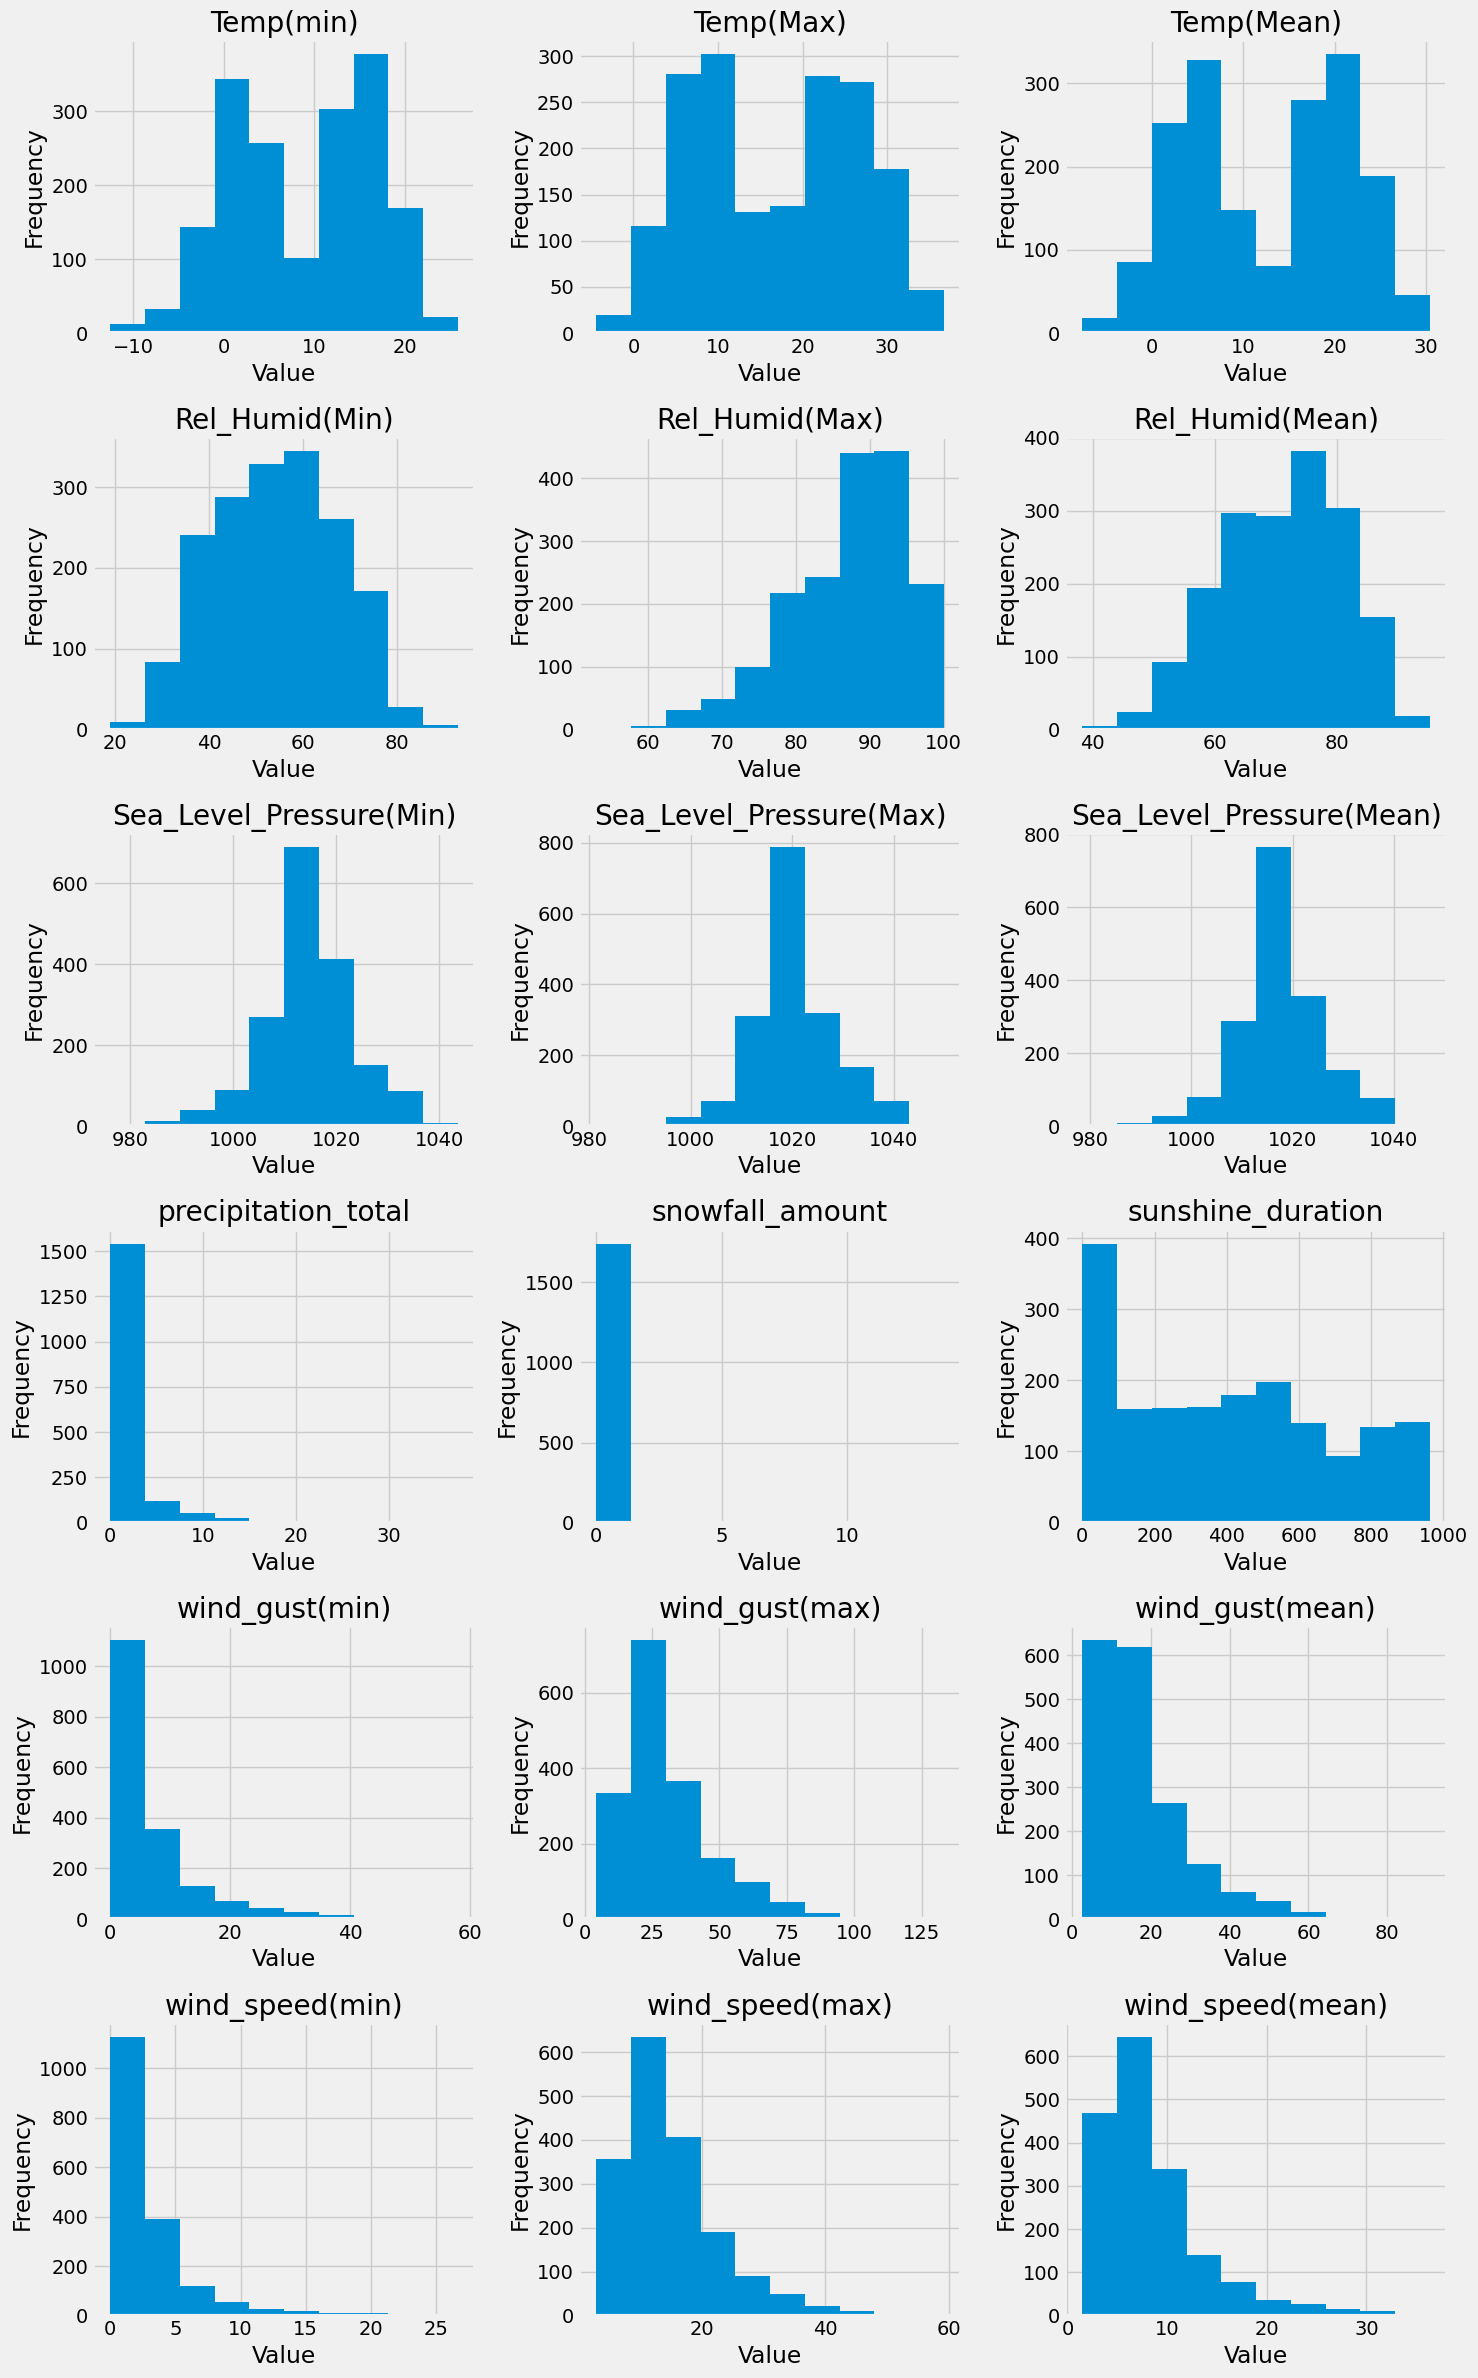

In [298]:
#histograms for each column
plot_histograms(df)

In [299]:
#correlation analysis between pairs of three -
temp_cols =["Temp(min)", "Temp(Max)", "Temp(Mean)"]
humid_cols =["Rel_Humid(Min)", "Rel_Humid(Max)", "Rel_Humid(Mean)"]
sea_level_cols = ["Sea_Level_Pressure(Min)", "Sea_Level_Pressure(Max)", "Sea_Level_Pressure(Mean)"]
wind_gust_cols = ["wind_gust(min)", "wind_gust(max)", "wind_gust(mean)"]
wind_speed_cols =["wind_speed(min)", "wind_speed(max)", "wind_speed(mean)"]

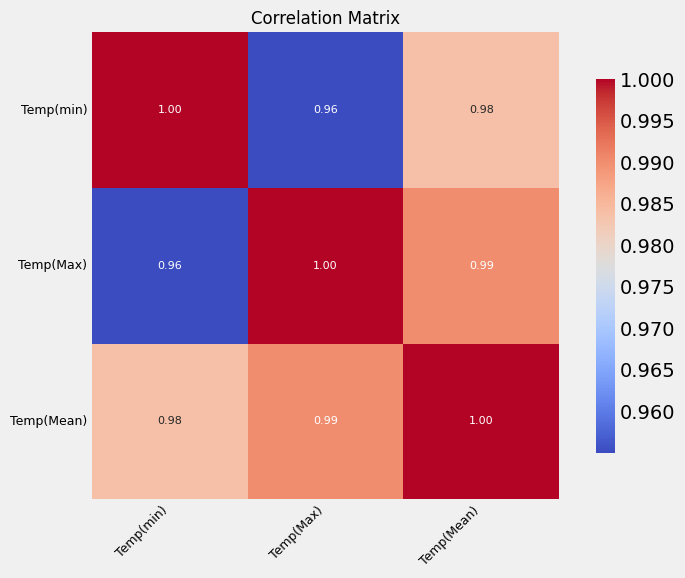

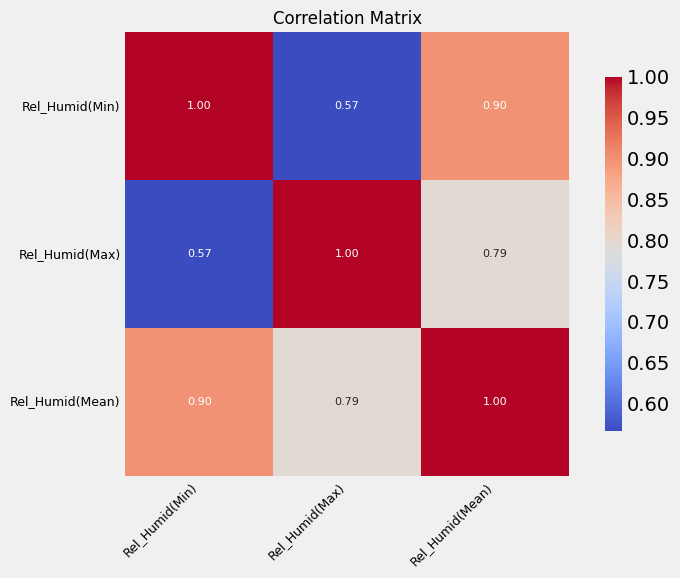

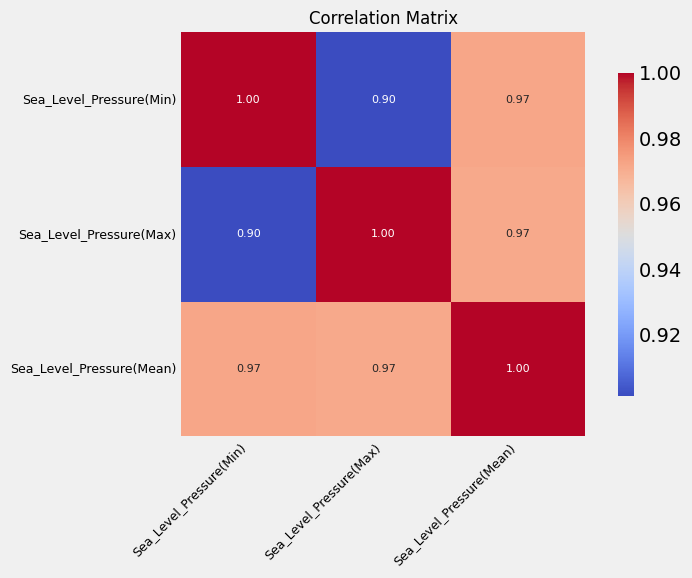

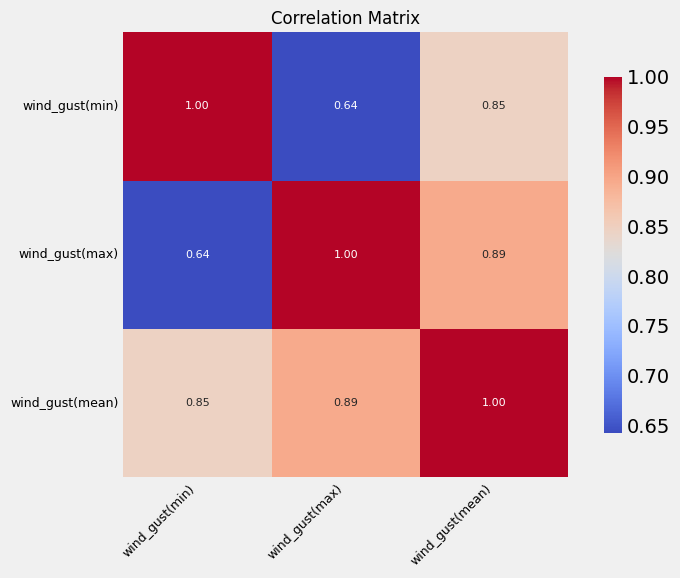

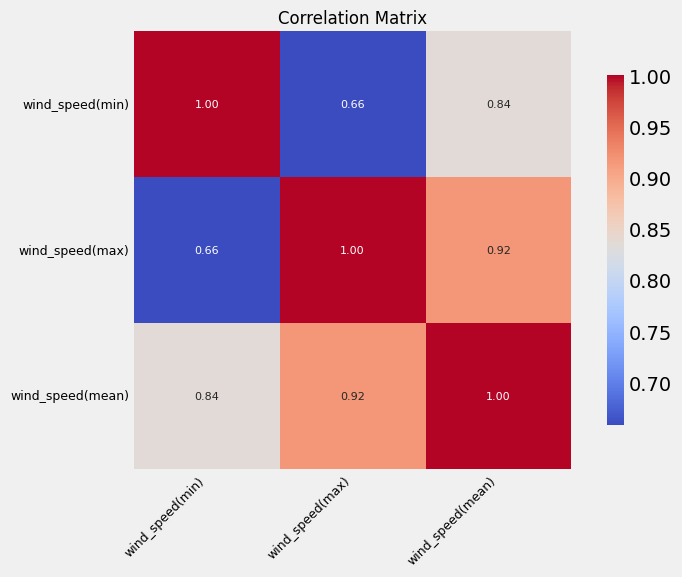

In [300]:
#temperature correlation
plot_correlation_matrix(df[temp_cols])

#humidity correlation
plot_correlation_matrix(df[humid_cols])

#sea_level correlation
plot_correlation_matrix(df[sea_level_cols])

#wind_gust correlation
plot_correlation_matrix(df[wind_gust_cols])

#wind_gust correlation
plot_correlation_matrix(df[wind_speed_cols])

Since there's such high collinearity between the variables, as we can see from the histogram and correlation matrix, we'll only take the mean

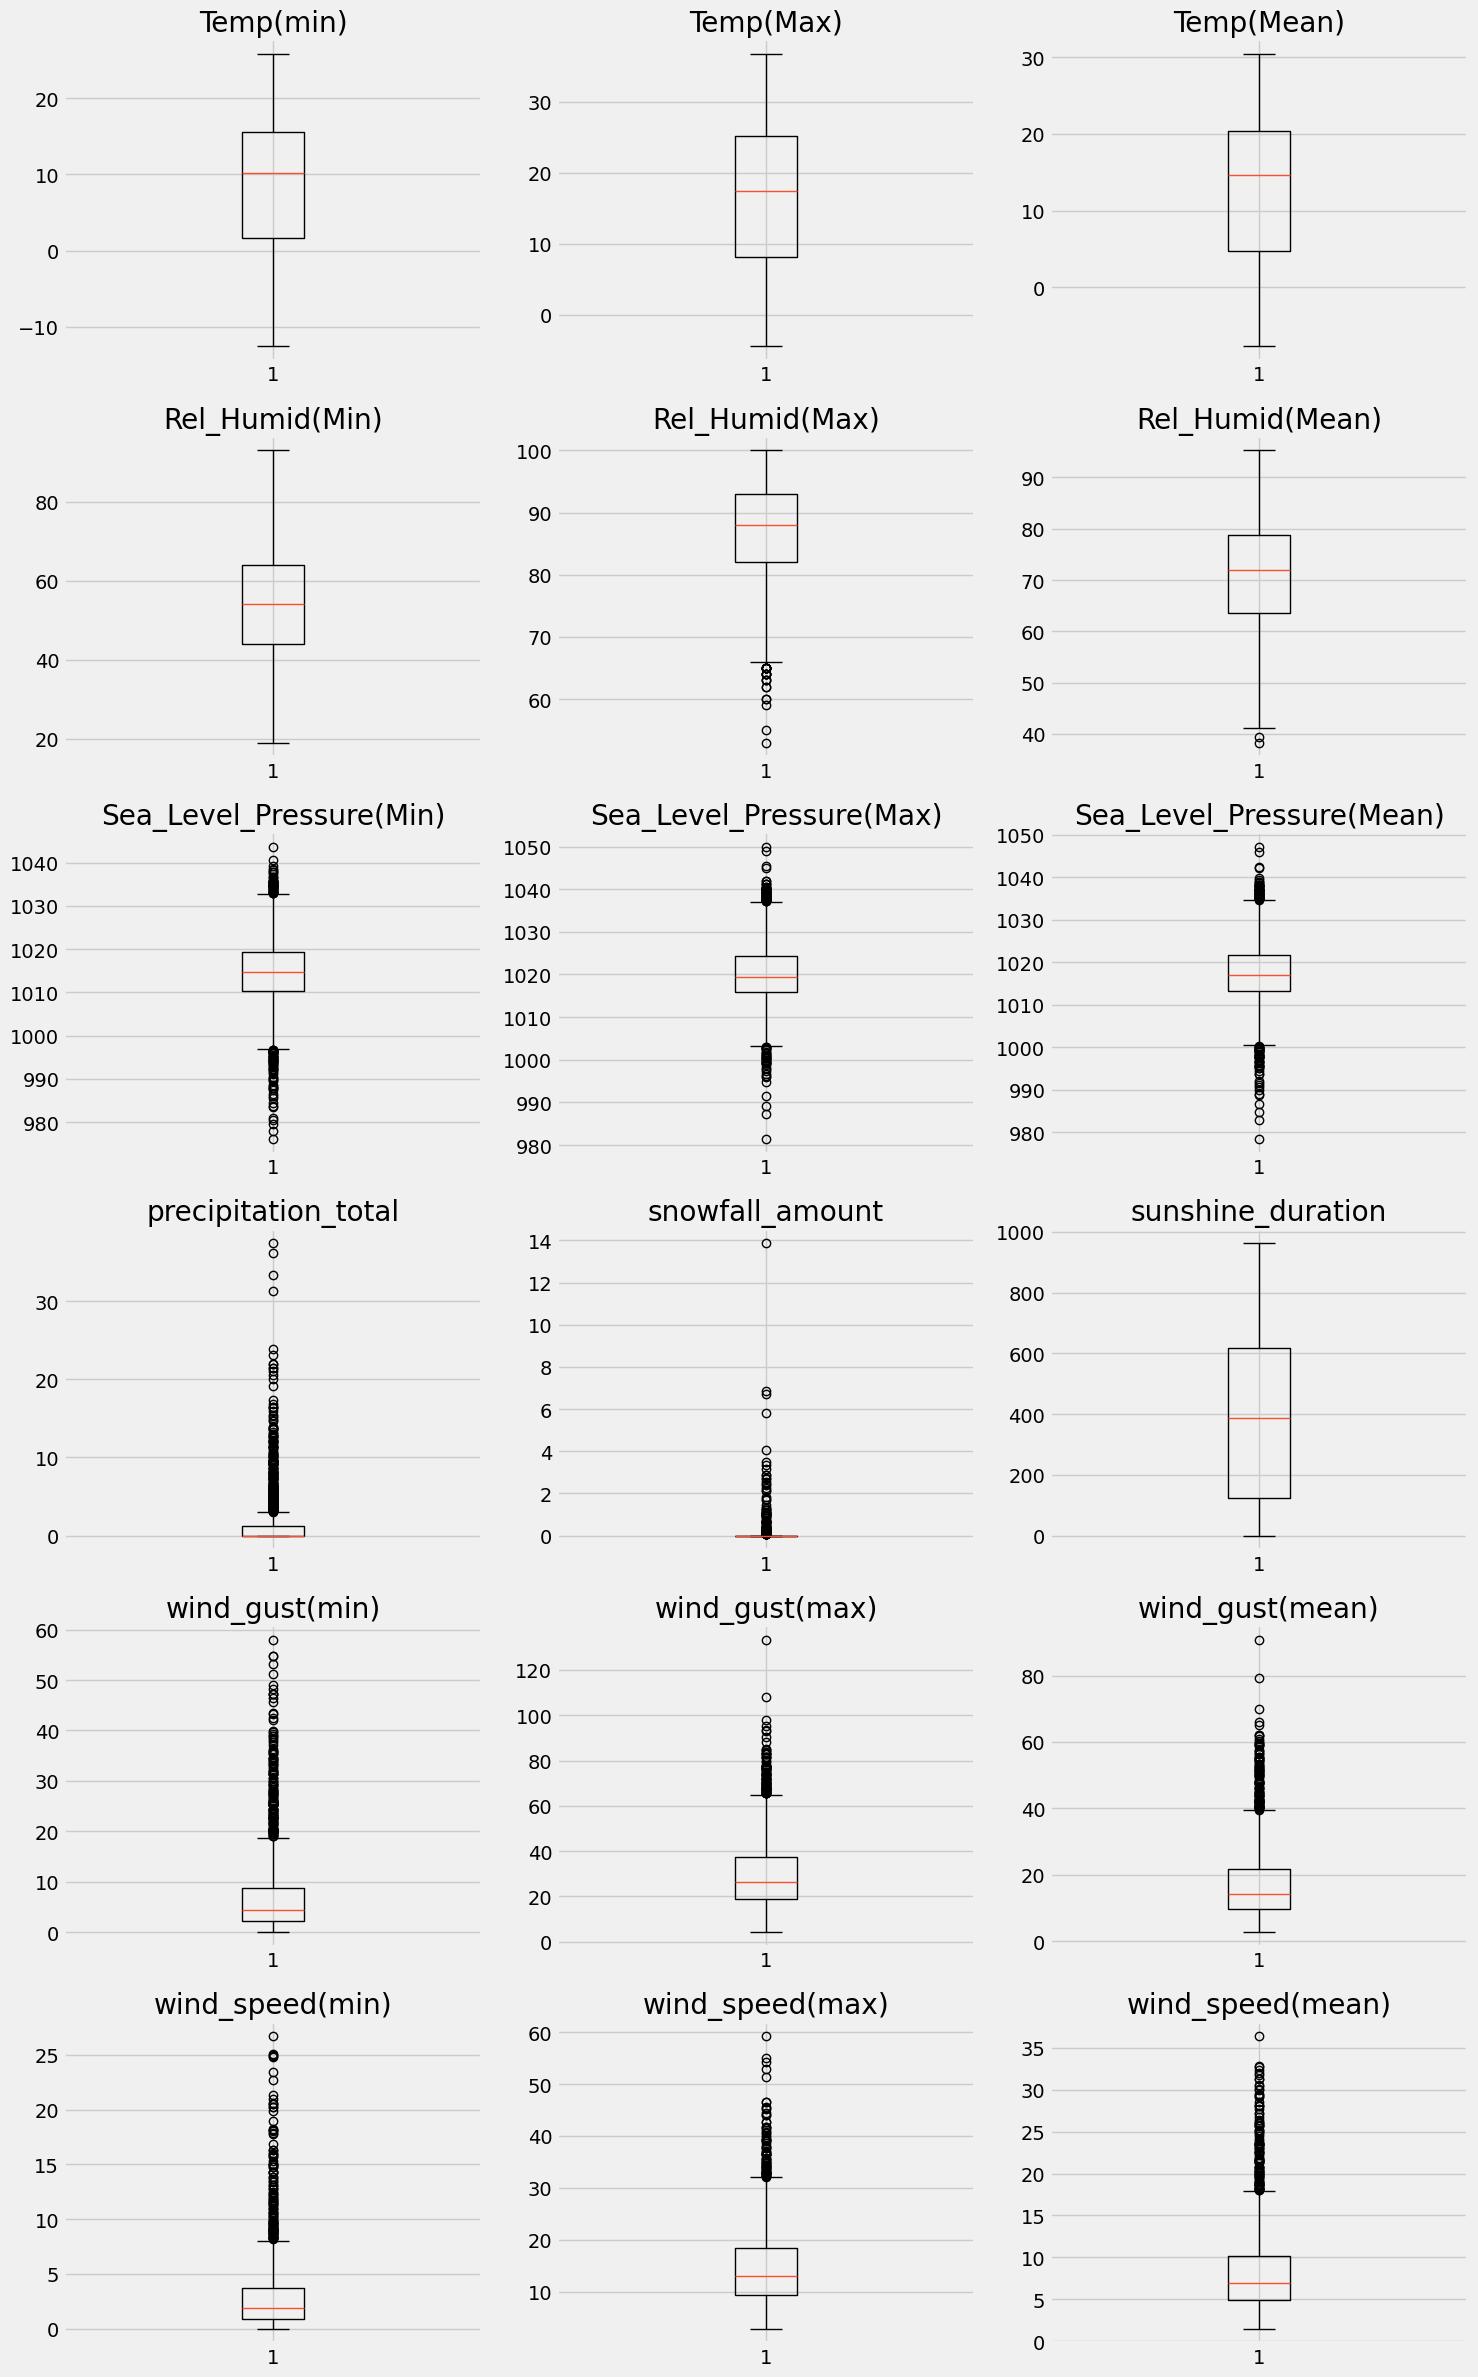

In [301]:
#plotting box_plots
plot_boxplots(df)

As we can see, some columns especially wind_speed, wind_gust, sea_level_pressure, rel_humid, precipitation and snow_fall amount have a high amount of outliers these might be important aspects

In [302]:
outlier_summary(df)

Rel_Humid(Max): 25 outliers and percentage is  (1.42%)
Rel_Humid(Mean): 2 outliers and percentage is  (0.11%)
Sea_Level_Pressure(Min): 109 outliers and percentage is  (6.18%)
Sea_Level_Pressure(Max): 97 outliers and percentage is  (5.50%)
Sea_Level_Pressure(Mean): 109 outliers and percentage is  (6.18%)
precipitation_total: 270 outliers and percentage is  (15.31%)
snowfall_amount: 111 outliers and percentage is  (6.30%)
wind_gust(min): 150 outliers and percentage is  (8.51%)
wind_gust(max): 87 outliers and percentage is  (4.93%)
wind_gust(mean): 108 outliers and percentage is  (6.13%)
wind_speed(min): 122 outliers and percentage is  (6.92%)
wind_speed(max): 76 outliers and percentage is  (4.31%)
wind_speed(mean): 108 outliers and percentage is  (6.13%)


## Pre-Processing

<h4> Based on the aspects found from EDA, we'll start pre-processing

first, thing to do is drop the high collinearity columns, we keep the mean since it shows the highest relationship with both the min and the max and is a perfect measure of both

In [303]:
# Define the list of column names
final_columns = [
    "Temp(Mean)",
    "Rel_Humid(Mean)",
    "Sea_Level_Pressure(Mean)",
    "precipitation_total", "snowfall_amount", "sunshine_duration",
    "wind_gust(mean)",
    "wind_speed(mean)"
]
df_prepped = df[final_columns].copy()
print(df_prepped.columns)
print(df_prepped.shape)
df_prepped.describe()

Index(['Temp(Mean)', 'Rel_Humid(Mean)', 'Sea_Level_Pressure(Mean)',
       'precipitation_total', 'snowfall_amount', 'sunshine_duration',
       'wind_gust(mean)', 'wind_speed(mean)'],
      dtype='object')
(1763, 8)


,Temp(Mean),Rel_Humid(Mean),Sea_Level_Pressure(Mean),precipitation_total,snowfall_amount,sunshine_duration,wind_gust(mean),wind_speed(mean)
count,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000
mean,12.717350,71.040509,1017.576393,1.502893,0.068015,399.168240,17.567084,8.418839
std,8.788555,10.012178,8.282298,3.496710,0.513935,294.660868,11.504750,5.205606
min,-7.628222,38.333332,978.450000,0.000000,0.000000,0.000000,2.715000,1.495064
25%,4.689279,63.520834,1013.233400,0.000000,0.000000,123.972160,9.765000,4.872080
50%,14.618446,72.000000,1016.954040,0.000000,0.000000,387.746280,14.145000,6.939507
75%,20.432404,78.750000,1021.760405,1.200000,0.000000,619.156720,21.667500,10.108294
max,30.425112,95.250000,1047.095800,37.399994,13.860001,962.283300,90.749990,36.360706


take a sample for the reduced data with original values for later testing

In [304]:
df_cluster_summary = df_prepped.copy()

Log transformation for columns with high skewness

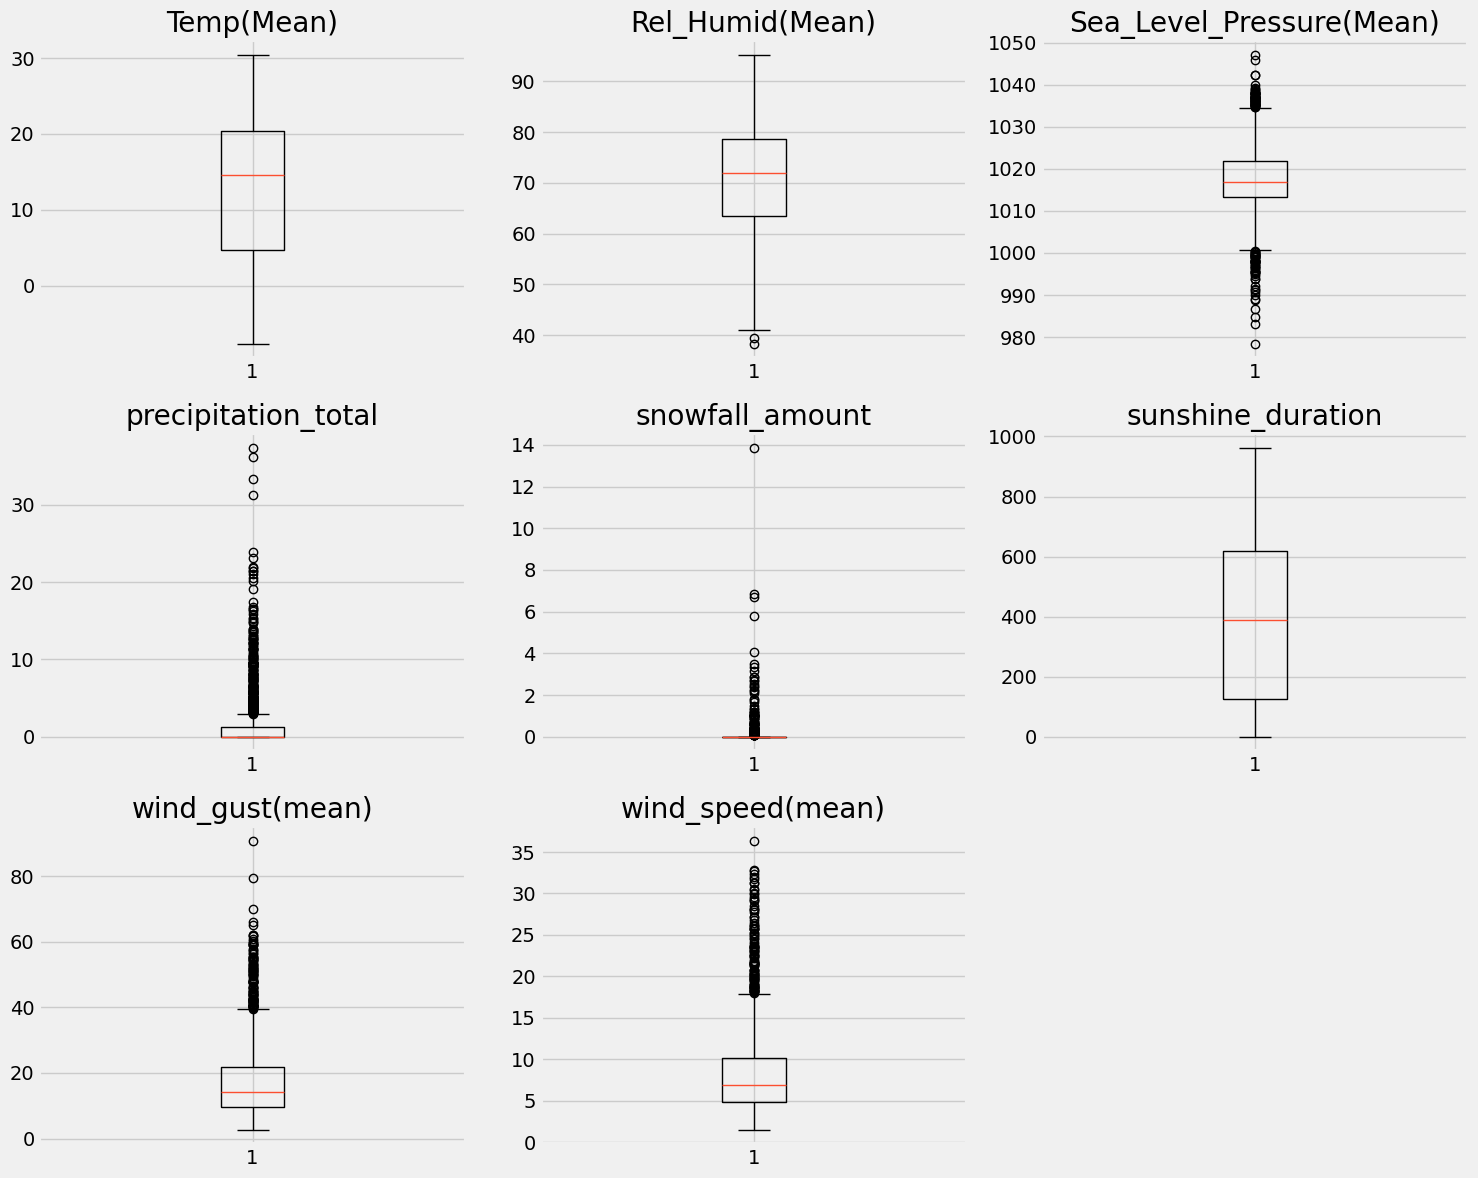

In [305]:
#getting boxplots again
plot_boxplots(df_prepped)

In [306]:
columns_to_transform =['Sea_Level_Pressure(Mean)','precipitation_total','snowfall_amount','wind_gust(mean)','wind_speed(mean)']
for col in columns_to_transform:
    if col in df_prepped.columns:
        df_prepped[col] = np.log1p(df_prepped[col])

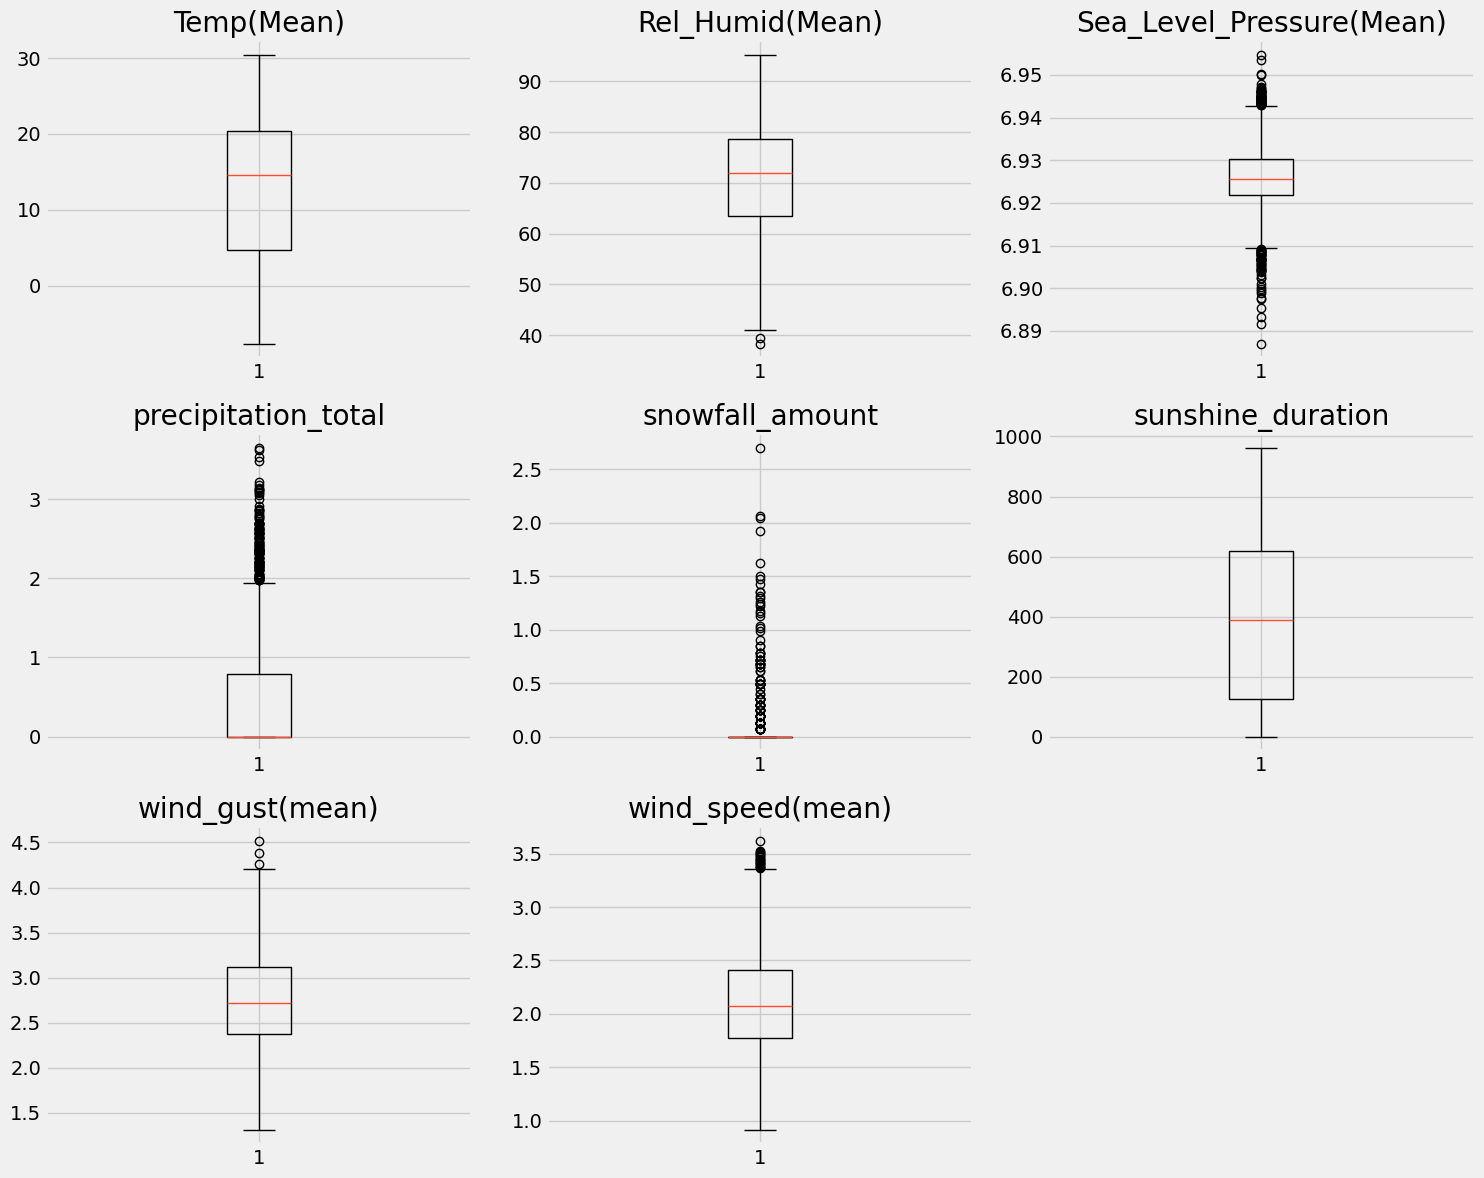

In [307]:
#plotting box plots again
plot_boxplots(df_prepped)

In [308]:
outlier_summary(df_prepped)

Rel_Humid(Mean): 2 outliers and percentage is  (0.11%)
Sea_Level_Pressure(Mean): 108 outliers and percentage is  (6.13%)
precipitation_total: 130 outliers and percentage is  (7.37%)
snowfall_amount: 111 outliers and percentage is  (6.30%)
wind_gust(mean): 3 outliers and percentage is  (0.17%)
wind_speed(mean): 20 outliers and percentage is  (1.13%)


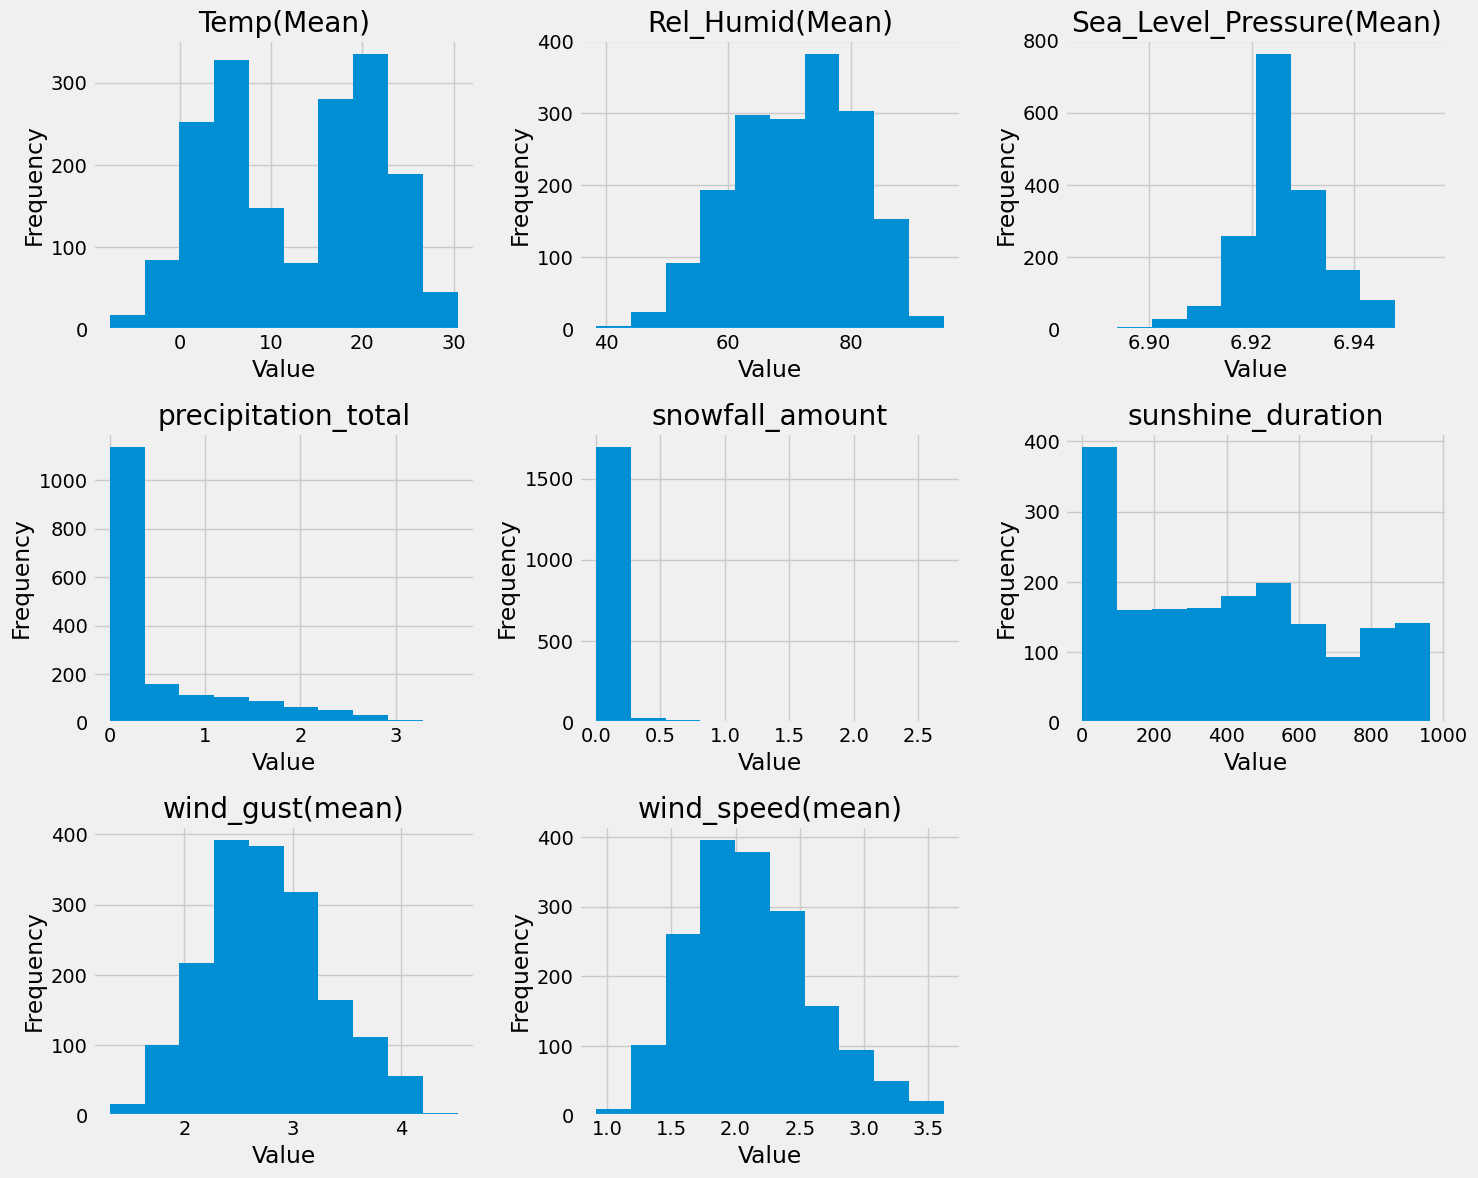

In [309]:
#creating histograms
plot_histograms(df_prepped)

Except for snow_fall amount and sea_level_pressure(mean) and precipitation outliers in other datasets are significantly reduced

<h4> Next we Apply Standard and Robust Scaling to the columns <h4>

for columns with outliers still, we apply robust scaling

In [310]:
#first a summary
df_prepped.describe()

,Temp(Mean),Rel_Humid(Mean),Sea_Level_Pressure(Mean),precipitation_total,snowfall_amount,sunshine_duration,wind_gust(mean),wind_speed(mean)
count,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000
mean,12.717350,71.040509,6.926128,0.500950,0.035246,399.168240,2.761925,2.121756
std,8.788555,10.012178,0.008134,0.764534,0.187278,294.660868,0.554333,0.474837
min,-7.628222,38.333332,6.886991,0.000000,0.000000,0.000000,1.312379,0.914314
25%,4.689279,63.520834,6.921888,0.000000,0.000000,123.972160,2.376299,1.770209
50%,14.618446,72.000000,6.925550,0.000000,0.000000,387.746280,2.717670,2.071851
75%,20.432404,78.750000,6.930261,0.788457,0.000000,619.156720,3.120932,2.407692
max,30.425112,95.250000,6.954730,3.648057,2.698673,962.283300,4.519067,3.620620


In [311]:
robust_scaling_columns =['Rel_Humid(Mean)','Sea_Level_Pressure(Mean)','precipitation_total','snowfall_amount','wind_gust(mean)','wind_speed(mean)']

In [312]:

rscaler = RobustScaler()
sscaler = StandardScaler()

# Robust scaling for selected columns
df_prepped[robust_scaling_columns] = rscaler.fit_transform(df_prepped[robust_scaling_columns])

# Standard scaling for the remaining columns
standard_columns = [col for col in df_prepped.columns if col not in robust_scaling_columns]
df_prepped[standard_columns] = sscaler.fit_transform(df_prepped[standard_columns])

In [313]:
#summary again
df_prepped.describe()

,Temp(Mean),Rel_Humid(Mean),Sea_Level_Pressure(Mean),precipitation_total,snowfall_amount,sunshine_duration,wind_gust(mean),wind_speed(mean)
count,1.763000e+03,1763.000000,1763.000000,1763.000000,1763.000000,1.763000e+03,1763.000000,1763.000000
mean,9.672732e-17,-0.063004,0.069054,0.635354,0.035246,5.642427e-17,0.059431,0.078284
std,1.000284e+00,0.657434,0.971539,0.969657,0.187278,1.000284e+00,0.744438,0.744863
min,-2.315664e+00,-2.210670,-4.605585,0.000000,0.000000,-1.355054e+00,-1.887228,-1.815793
25%,-9.137280e-01,-0.556772,-0.437366,0.000000,0.000000,-9.342067e-01,-0.458443,-0.473177
50%,2.163763e-01,0.000000,0.000000,0.000000,0.000000,-3.877407e-02,0.000000,0.000000
75%,8.781015e-01,0.443228,0.562634,1.000000,0.000000,7.467938e-01,0.541557,0.526823
max,2.015438e+00,1.526676,3.485373,4.626829,2.698673,1.911604e+00,2.419175,2.429505


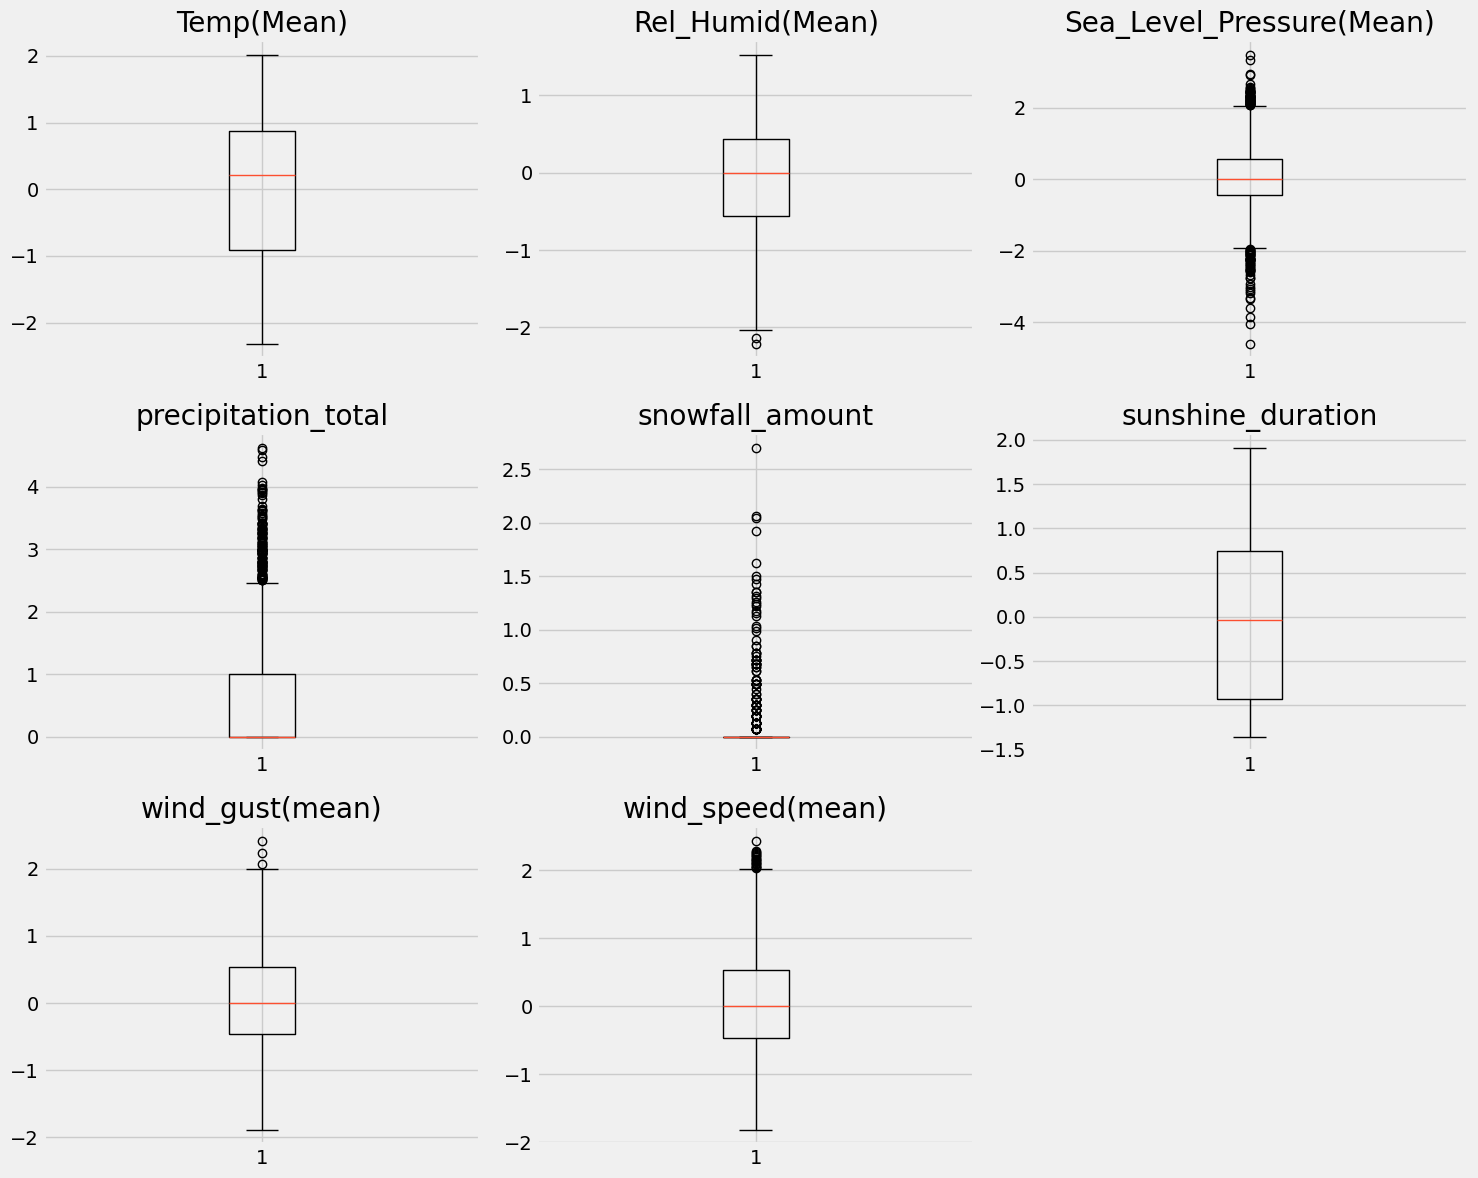

In [314]:
#creating box plots again 
plot_boxplots(df_prepped)

In [315]:
outlier_summary(df_prepped)

Rel_Humid(Mean): 2 outliers and percentage is  (0.11%)
Sea_Level_Pressure(Mean): 108 outliers and percentage is  (6.13%)
precipitation_total: 130 outliers and percentage is  (7.37%)
snowfall_amount: 111 outliers and percentage is  (6.30%)
wind_gust(mean): 3 outliers and percentage is  (0.17%)
wind_speed(mean): 20 outliers and percentage is  (1.13%)


while outliers still exist, as they represent important data, all the columns fit the same distribution

<h4> Dimensionality Reduction with PCA <h4>

In [316]:
from sklearn.decomposition import PCA

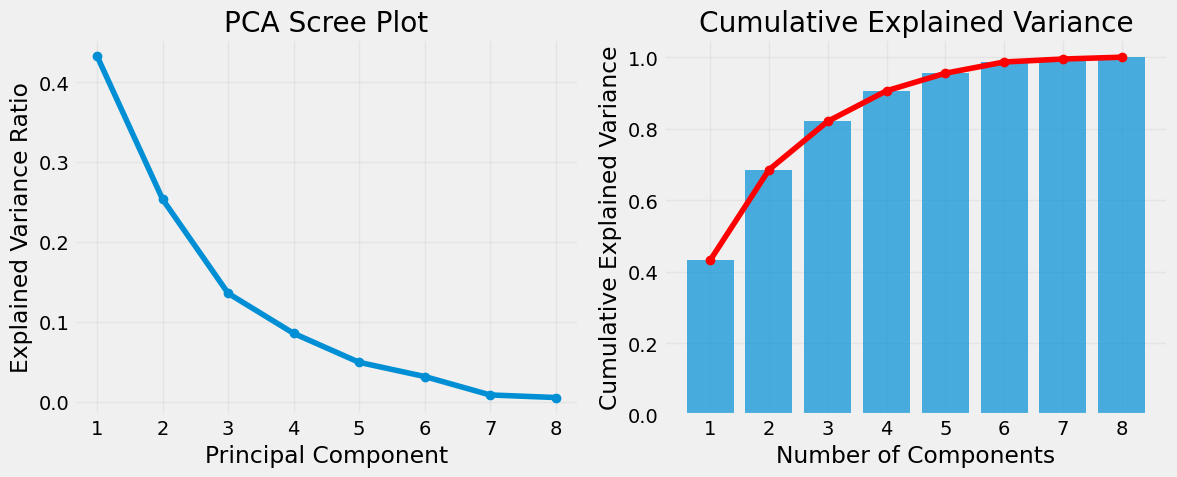

In [317]:
# Fit PCA with max components
max_components = 8
pca = PCA(n_components=max_components)
pca.fit(df_prepped)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot both in one figure
plt.figure(figsize=(12, 5))

# Scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, max_components + 1), explained_var, marker='o', linestyle='-')
plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, max_components + 1))
plt.grid(alpha=0.3)

# Cumulative explained variance
plt.subplot(1, 2, 2)
plt.bar(range(1, max_components + 1), cumulative_var, alpha=0.7)
plt.plot(range(1, max_components + 1), cumulative_var, marker='o', color='r')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(1, max_components + 1))
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

using the elbow method and the plots, we can see that after 4 components the difference is very minimal,so we fit pca to 4 components

In [318]:
import pandas as pd
from sklearn.decomposition import PCA

# Make a copy
df_prepped_pca = df_prepped.copy()

# Fit PCA
pca = PCA(n_components=4)
pca_array = pca.fit_transform(df_prepped_pca)

# Convert to DataFrame
df_prepped_pca = pd.DataFrame(
    pca_array,
    columns=[f'PC{i+1}' for i in range(pca_array.shape[1])],
    index=df_prepped.index  # preserve original index
)

df_prepped_pca.shape
df_prepped_pca.describe()

,PC1,PC2,PC3,PC4
count,1.763000e+03,1.763000e+03,1.763000e+03,1.763000e+03
mean,4.836366e-17,5.642427e-17,2.418183e-17,-8.060610e-18
std,1.536124e+00,1.175554e+00,8.602456e-01,6.828515e-01
min,-4.150102e+00,-2.958370e+00,-2.570699e+00,-3.052846e+00
25%,-1.122837e+00,-8.398811e-01,-5.679065e-01,-3.801744e-01
50%,4.692088e-02,-2.419284e-01,-1.825731e-02,4.874653e-02
75%,1.279571e+00,8.268322e-01,5.374746e-01,4.368110e-01
max,3.107022e+00,3.404632e+00,3.050745e+00,1.891229e+00


# Clustering

In [320]:
global_results_df = pd.DataFrame(columns=['experiment', 'n_clusters', 'inertia', 'silhouette', 'davies_bouldin','BIC'])

## Clustering K-Means

<h4> First without PCA <h4>

In [321]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score

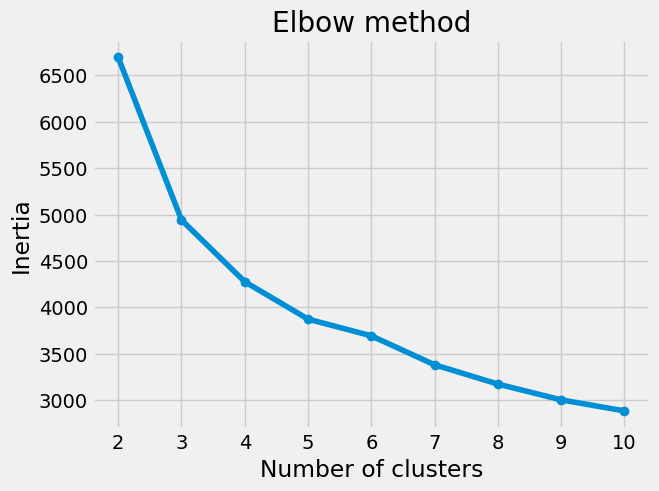

In [322]:
inertias = []
sil_score =[]
db_score =[]
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(df_prepped)
    score = silhouette_score(df_prepped,kmeans.labels_)
    db_index = davies_bouldin_score(df_prepped, kmeans.labels_)
    inertias.append(kmeans.inertia_)
    sil_score.append(score)
    db_score.append(db_index)    

plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

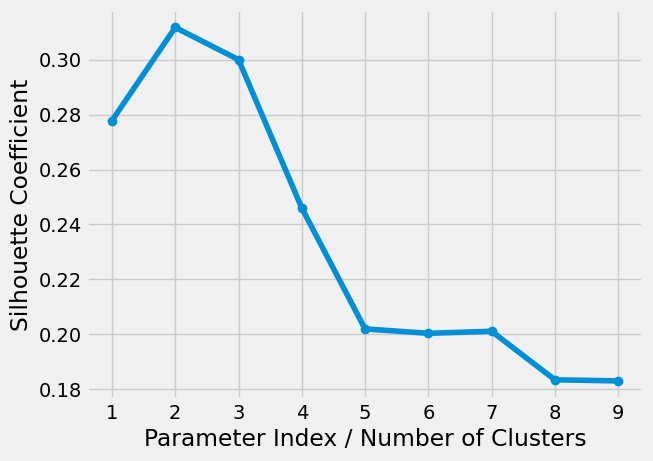

In [323]:
plot_silhouette_score(sil_score)

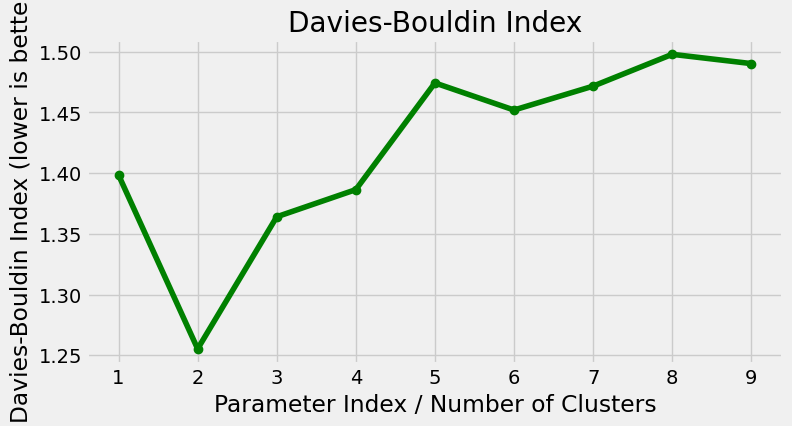

In [324]:
plot_db_score(db_score=db_score)

In [325]:
#getting values for each
print(max(sil_score))
print(min(db_score))

0.31168666732853156
1.2552265066457964


In [326]:
experiment_name = 'KMeans_df_prepped'

# Create a temporary DataFrame from your lists
temp_results = pd.DataFrame({
    'experiment': experiment_name,
    'n_clusters': list(range(2, 11)),
    'inertia': inertias,
    'silhouette': sil_score,
    'davies_bouldin': db_score
})

# Append all at once
global_results_df = pd.concat([global_results_df, temp_results], ignore_index=True)

# Show global results
print(global_results_df)

          experiment n_clusters      inertia  silhouette  davies_bouldin  BIC
0  KMeans_df_prepped          2  6693.920697    0.277800        1.398421  NaN
1  KMeans_df_prepped          3  4942.489152    0.311687        1.255227  NaN
2  KMeans_df_prepped          4  4276.800556    0.299972        1.364029  NaN
3  KMeans_df_prepped          5  3873.902878    0.245995        1.386400  NaN
4  KMeans_df_prepped          6  3693.820325    0.202002        1.474295  NaN
5  KMeans_df_prepped          7  3381.773102    0.200403        1.451963  NaN
6  KMeans_df_prepped          8  3174.017185    0.201140        1.471638  NaN
7  KMeans_df_prepped          9  3003.976363    0.183482        1.497869  NaN
8  KMeans_df_prepped         10  2884.685291    0.183083        1.490227  NaN


C:\Users\OMNI BOOK\AppData\Local\Temp\ipykernel_25504\3869774452.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  global_results_df = pd.concat([global_results_df, temp_results], ignore_index=True)


<h4>Now with PCA <h4>

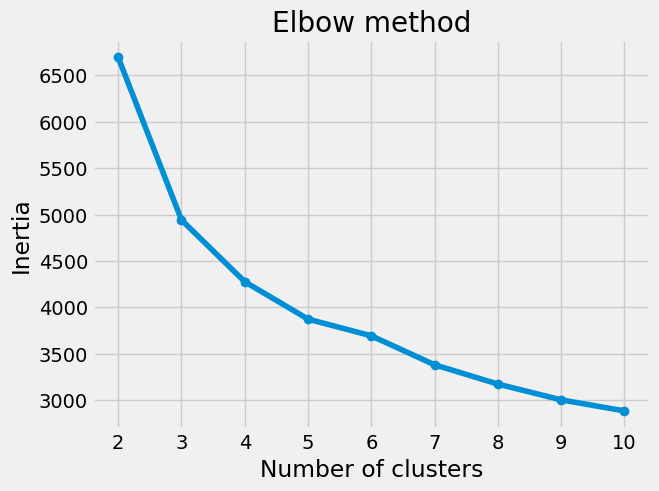

In [327]:
inertias_pca = []
sil_score_pca =[]
db_score_pca =[]
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(df_prepped_pca)
    score = silhouette_score(df_prepped_pca,kmeans.labels_)
    db_index = davies_bouldin_score(df_prepped_pca, kmeans.labels_)
    inertias_pca.append(kmeans.inertia_)
    sil_score_pca.append(score)
    db_score_pca.append(db_index)    

plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

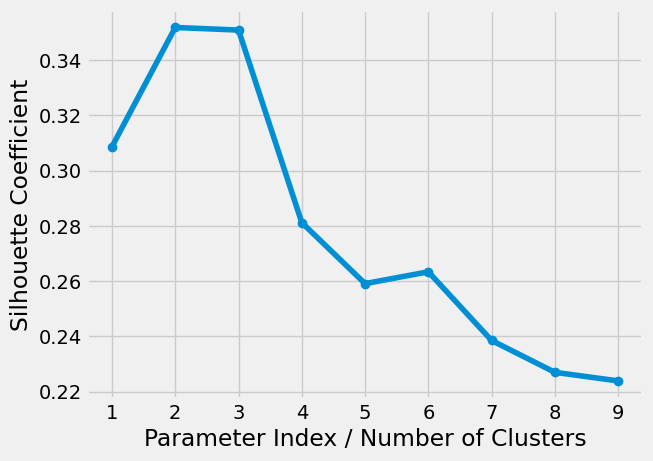

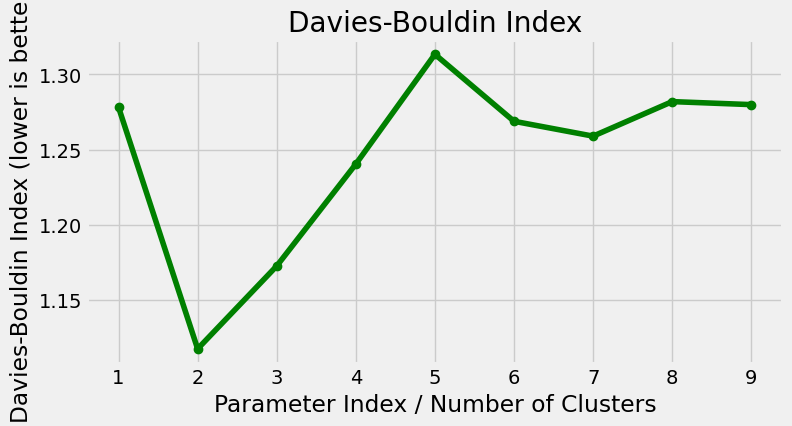

In [328]:
plot_silhouette_score(sil_score_pca)
plot_db_score(db_score_pca)

In [329]:
experiment_name = 'KMeans_df_prepped_pca'

# Create a temporary DataFrame from your lists
temp_results = pd.DataFrame({
    'experiment': experiment_name,
    'n_clusters': list(range(2, 11)),
    'inertia': inertias_pca,
    'silhouette': sil_score_pca,
    'davies_bouldin': db_score_pca
})

# Append all at once
global_results_df = pd.concat([global_results_df, temp_results], ignore_index=True)

# Show global results
global_results_df

,experiment,n_clusters,inertia,silhouette,davies_bouldin,BIC
0,KMeans_df_prepped,2,6693.920697,0.277800,1.398421,NaN
1,KMeans_df_prepped,3,4942.489152,0.311687,1.255227,NaN
2,KMeans_df_prepped,4,4276.800556,0.299972,1.364029,NaN
3,KMeans_df_prepped,5,3873.902878,0.245995,1.386400,NaN
4,KMeans_df_prepped,6,3693.820325,0.202002,1.474295,NaN
5,KMeans_df_prepped,7,3381.773102,0.200403,1.451963,NaN
6,KMeans_df_prepped,8,3174.017185,0.201140,1.471638,NaN
7,KMeans_df_prepped,9,3003.976363,0.183482,1.497869,NaN
8,KMeans_df_prepped,10,2884.685291,0.183083,1.490227,NaN
9,KMeans_df_prepped_pca,2,5789.708785,0.308635,1.278080,NaN


Finally, visualizing with PCA = 2 the clusters

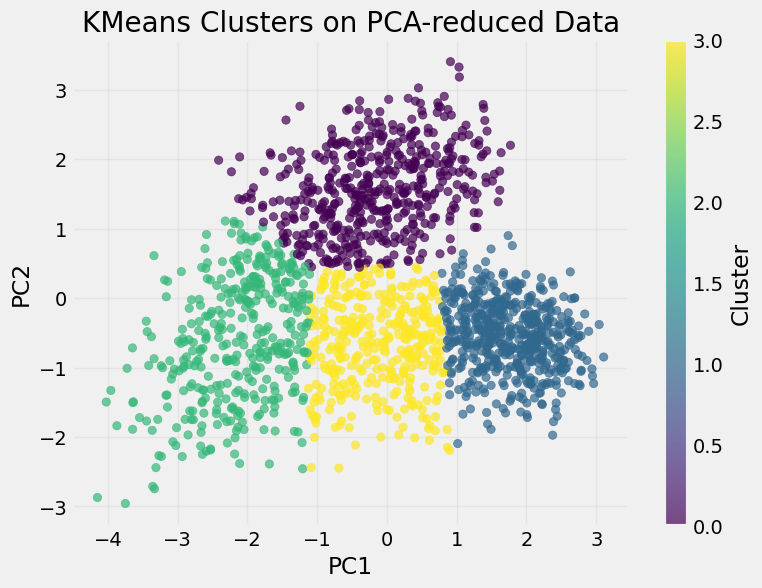

In [330]:
pca= PCA(n_components=2)
visualization_df = pca.fit_transform(df_prepped)

# 1. PCA to 2D
pca = PCA(n_components=2)
visualization_df = pca.fit_transform(df_prepped)

# 2. KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(visualization_df)
labels = kmeans.labels_  # cluster labels for each point

# 3. Plotting
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    visualization_df[:, 0], 
    visualization_df[:, 1], 
    c=labels,           # color by cluster
    cmap='viridis',      # color map
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters on PCA-reduced Data")
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

In [331]:
df_cluster_summary['labels'] = kmeans.labels_

# Group by KMeans labels and describe numeric variables
df_cluster_summary.groupby('labels').mean()


,Temp(Mean),Rel_Humid(Mean),Sea_Level_Pressure(Mean),precipitation_total,snowfall_amount,sunshine_duration,wind_gust(mean),wind_speed(mean)
labels,,,,,,,,
0,3.557835,75.620672,1025.941990,0.170672,0.034073,316.977220,15.267403,7.538313
1,21.586009,62.125942,1017.447032,0.107910,0.000000,738.581981,10.825423,5.446406
2,7.921772,78.395341,1010.505616,5.024147,0.270079,88.524431,30.215826,14.097782
3,17.203958,70.158796,1013.840693,1.650833,0.000778,339.397088,17.260958,7.993900


<h4> DBSCAN clustering <h4>

In [332]:
from sklearn.cluster import DBSCAN

similarly, first without PCA

In [335]:
df_prepped.shape
df_prepped.describe()

,Temp(Mean),Rel_Humid(Mean),Sea_Level_Pressure(Mean),precipitation_total,snowfall_amount,sunshine_duration,wind_gust(mean),wind_speed(mean)
count,1.763000e+03,1763.000000,1763.000000,1763.000000,1763.000000,1.763000e+03,1763.000000,1763.000000
mean,9.672732e-17,-0.063004,0.069054,0.635354,0.035246,5.642427e-17,0.059431,0.078284
std,1.000284e+00,0.657434,0.971539,0.969657,0.187278,1.000284e+00,0.744438,0.744863
min,-2.315664e+00,-2.210670,-4.605585,0.000000,0.000000,-1.355054e+00,-1.887228,-1.815793
25%,-9.137280e-01,-0.556772,-0.437366,0.000000,0.000000,-9.342067e-01,-0.458443,-0.473177
50%,2.163763e-01,0.000000,0.000000,0.000000,0.000000,-3.877407e-02,0.000000,0.000000
75%,8.781015e-01,0.443228,0.562634,1.000000,0.000000,7.467938e-01,0.541557,0.526823
max,2.015438e+00,1.526676,3.485373,4.626829,2.698673,1.911604e+00,2.419175,2.429505


In [ ]:
# Parameter grid for DBSCAN
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples = 5

# Lists to store metrics
sil_scores = []
db_scores = []
n_clusters_df = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(df_prepped)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_clusters_df.append(n_clusters)
    
    if n_clusters > 1:
        sil_scores.append(silhouette_score(df_prepped, labels))
        db_scores.append(davies_bouldin_score(df_prepped, labels))
    else:
        sil_scores.append(np.nan)
        db_scores.append(np.nan)


In [337]:
experiment_name = 'DBSCAN_df_prepped'

# Temporary DataFrame for appending
temp_results = pd.DataFrame({
    'experiment': experiment_name,
    'parameter': eps_values,
    'n_clusters': n_clusters_df,
    'silhouette': sil_scores,
    'davies_bouldin': db_scores
})

# Append all at once
global_results_df = pd.concat([global_results_df, temp_results], ignore_index=True)

# Show updated global results
global_results_df

,experiment,n_clusters,inertia,silhouette,davies_bouldin,BIC,parameter
0,KMeans_df_prepped,2,6693.920697,0.277800,1.398421,NaN,NaN
1,KMeans_df_prepped,3,4942.489152,0.311687,1.255227,NaN,NaN
2,KMeans_df_prepped,4,4276.800556,0.299972,1.364029,NaN,NaN
3,KMeans_df_prepped,5,3873.902878,0.245995,1.386400,NaN,NaN
4,KMeans_df_prepped,6,3693.820325,0.202002,1.474295,NaN,NaN
5,KMeans_df_prepped,7,3381.773102,0.200403,1.451963,NaN,NaN
6,KMeans_df_prepped,8,3174.017185,0.201140,1.471638,NaN,NaN
7,KMeans_df_prepped,9,3003.976363,0.183482,1.497869,NaN,NaN
8,KMeans_df_prepped,10,2884.685291,0.183083,1.490227,NaN,NaN
9,KMeans_df_prepped_pca,2,5789.708785,0.308635,1.278080,NaN,NaN


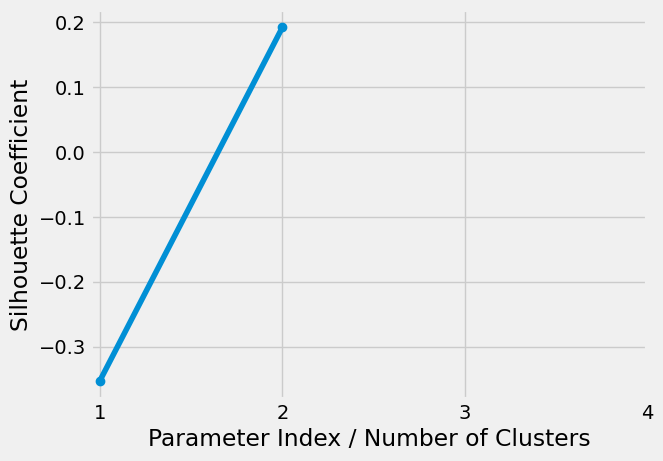

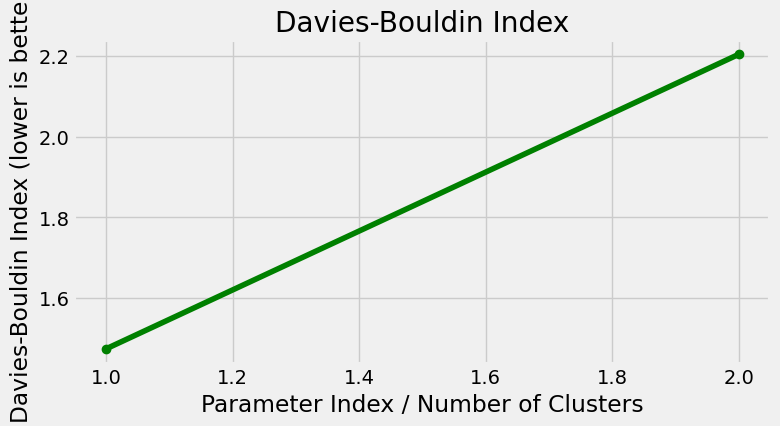

In [339]:
plot_silhouette_score(sil_scores)
plot_db_score(db_scores)

Now for the dataframe with PCA

In [340]:
# Parameter grid for DBSCAN
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples = 5

# Lists to store metrics
sil_scores = []
db_scores = []
n_clusters_df = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(df_prepped_pca)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_clusters_df.append(n_clusters)
    
    if n_clusters > 1:
        sil_scores.append(silhouette_score(df_prepped_pca, labels))
        db_scores.append(davies_bouldin_score(df_prepped_pca, labels))
    else:
        sil_scores.append(np.nan)
        db_scores.append(np.nan)


In [341]:
experiment_name = 'DBSCAN_df_prepped_pca'

# Temporary DataFrame for appending
temp_results = pd.DataFrame({
    'experiment': experiment_name,
    'parameter': eps_values,
    'n_clusters': n_clusters_df,
    'silhouette': sil_scores,
    'davies_bouldin': db_scores
})

# Append all at once
global_results_df = pd.concat([global_results_df, temp_results], ignore_index=True)

# Show updated global results
global_results_df

,experiment,n_clusters,inertia,silhouette,davies_bouldin,BIC,parameter
0,KMeans_df_prepped,2,6693.920697,0.277800,1.398421,NaN,NaN
1,KMeans_df_prepped,3,4942.489152,0.311687,1.255227,NaN,NaN
2,KMeans_df_prepped,4,4276.800556,0.299972,1.364029,NaN,NaN
3,KMeans_df_prepped,5,3873.902878,0.245995,1.386400,NaN,NaN
4,KMeans_df_prepped,6,3693.820325,0.202002,1.474295,NaN,NaN
5,KMeans_df_prepped,7,3381.773102,0.200403,1.451963,NaN,NaN
6,KMeans_df_prepped,8,3174.017185,0.201140,1.471638,NaN,NaN
7,KMeans_df_prepped,9,3003.976363,0.183482,1.497869,NaN,NaN
8,KMeans_df_prepped,10,2884.685291,0.183083,1.490227,NaN,NaN
9,KMeans_df_prepped_pca,2,5789.708785,0.308635,1.278080,NaN,NaN


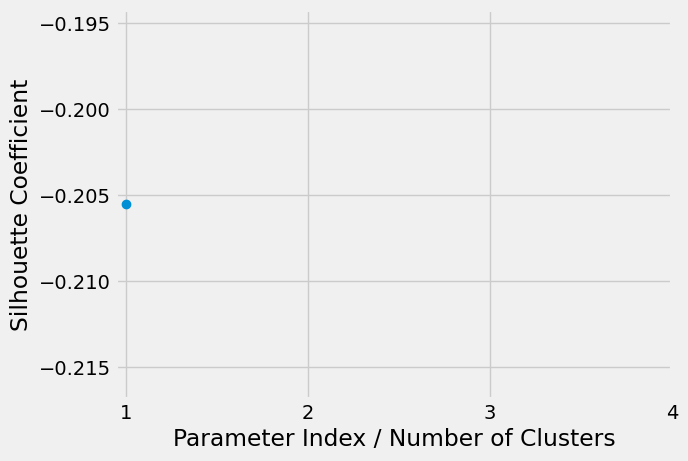

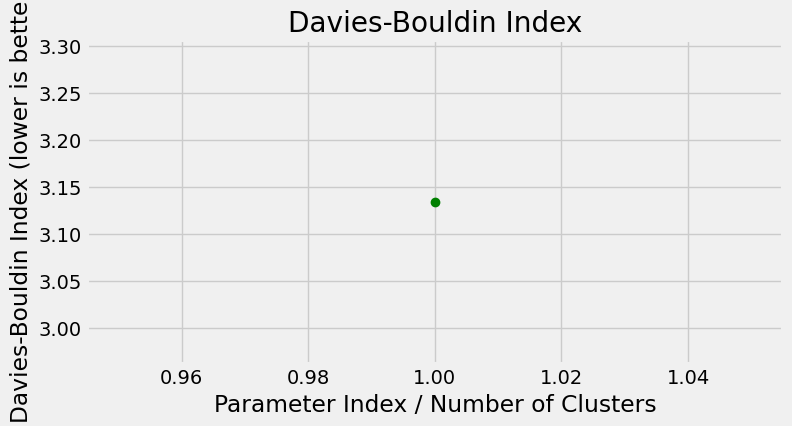

In [342]:
plot_silhouette_score(sil_scores)
plot_db_score(db_scores)

<h4> Gaussian Mixture Models <h4>

In [343]:
from sklearn.mixture import GaussianMixture

first without PCA

In [344]:
results = []
cluster_range=range(2,11)
sil_score_gmm =[]
db_score_gmm =[]
bic_scores=[]    
for k in cluster_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(df_prepped)
    labels = gmm.predict(df_prepped)
    
    # Metrics
    sil_score_gmm.append(silhouette_score(df_prepped, labels) if k > 1 else np.nan)
    db_score_gmm.append(davies_bouldin_score(df_prepped, labels) if k > 1 else np.nan)
    bic_scores.append(gmm.bic(df_prepped))

In [345]:
experiment_name = 'GMM_df_prepped'

# Temporary DataFrame for appending
temp_results = pd.DataFrame({
    'experiment': experiment_name,
    'n_clusters': range(2,11),
    'silhouette': sil_score_gmm,
    'davies_bouldin': db_score_gmm,
    'BIC': bic_scores
})

# Append all at once
global_results_df = pd.concat([global_results_df, temp_results], ignore_index=True)

# Show updated global results
global_results_df

C:\Users\OMNI BOOK\AppData\Local\Temp\ipykernel_25504\1932876190.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  global_results_df = pd.concat([global_results_df, temp_results], ignore_index=True)


,experiment,n_clusters,inertia,silhouette,davies_bouldin,BIC,parameter
0,KMeans_df_prepped,2,6693.920697,0.277800,1.398421,NaN,NaN
1,KMeans_df_prepped,3,4942.489152,0.311687,1.255227,NaN,NaN
2,KMeans_df_prepped,4,4276.800556,0.299972,1.364029,NaN,NaN
3,KMeans_df_prepped,5,3873.902878,0.245995,1.386400,NaN,NaN
4,KMeans_df_prepped,6,3693.820325,0.202002,1.474295,NaN,NaN
5,KMeans_df_prepped,7,3381.773102,0.200403,1.451963,NaN,NaN
6,KMeans_df_prepped,8,3174.017185,0.201140,1.471638,NaN,NaN
7,KMeans_df_prepped,9,3003.976363,0.183482,1.497869,NaN,NaN
8,KMeans_df_prepped,10,2884.685291,0.183083,1.490227,NaN,NaN
9,KMeans_df_prepped_pca,2,5789.708785,0.308635,1.278080,NaN,NaN


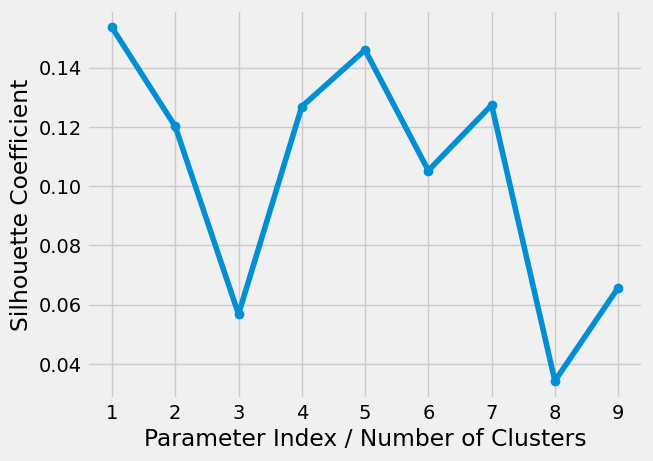

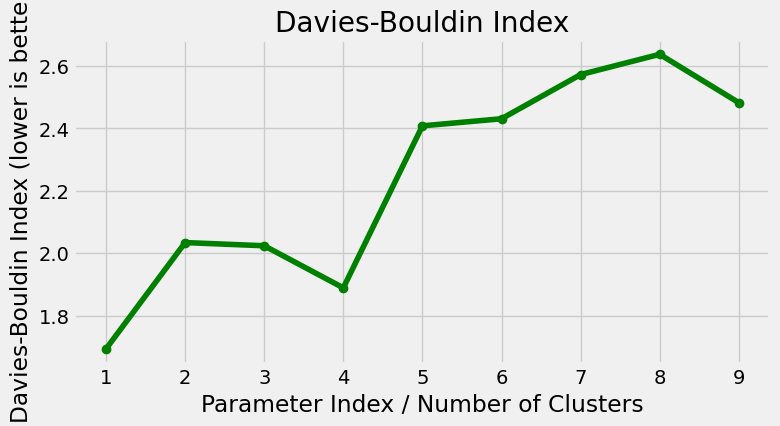

In [346]:
plot_silhouette_score(sil_score_gmm)
plot_db_score(db_score_gmm)

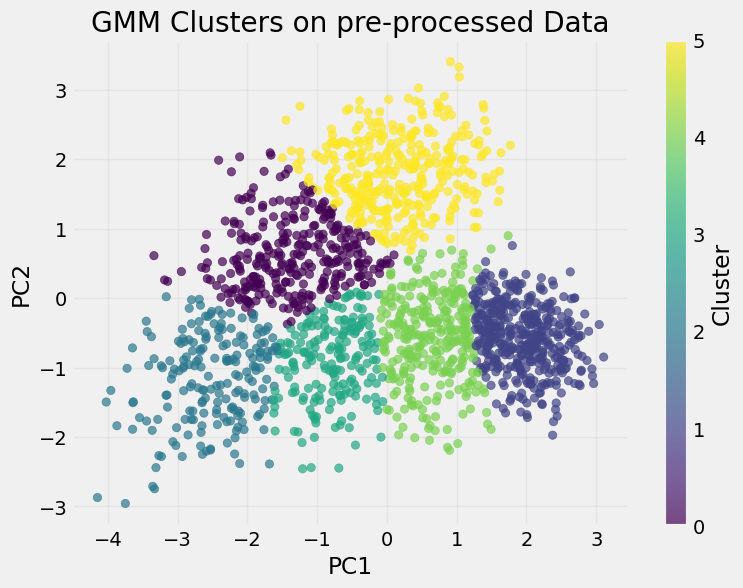

In [352]:
# 2. PCA
pca = PCA(n_components=2)
visualization_df = pca.fit_transform(df_prepped)

# 3. GMM Clustering
# FIX: Use .predict() to get the labels
gmm = GaussianMixture(n_components=6, random_state=42)
gmm.fit(visualization_df)
labels = gmm.predict(visualization_df)  

# 4. Plotting
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    visualization_df[:, 0], 
    visualization_df[:, 1], 
    c=labels,           
    cmap='viridis',     
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters on pre-processed Data") # Updated title to match algorithm
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

with PCA

In [347]:
df_prepped_pca.shape
df_prepped_pca.describe()

,PC1,PC2,PC3,PC4
count,1.763000e+03,1.763000e+03,1.763000e+03,1.763000e+03
mean,4.836366e-17,5.642427e-17,2.418183e-17,-8.060610e-18
std,1.536124e+00,1.175554e+00,8.602456e-01,6.828515e-01
min,-4.150102e+00,-2.958370e+00,-2.570699e+00,-3.052846e+00
25%,-1.122837e+00,-8.398811e-01,-5.679065e-01,-3.801744e-01
50%,4.692088e-02,-2.419284e-01,-1.825731e-02,4.874653e-02
75%,1.279571e+00,8.268322e-01,5.374746e-01,4.368110e-01
max,3.107022e+00,3.404632e+00,3.050745e+00,1.891229e+00


In [348]:
results = []
cluster_range=range(2,11)
sil_score_gmm =[]
db_score_gmm =[]
bic_scores=[]    
for k in cluster_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(df_prepped_pca)
    labels = gmm.predict(df_prepped_pca)
    
    # Metrics
    sil_score_gmm.append(silhouette_score(df_prepped_pca, labels) if k > 1 else np.nan)
    db_score_gmm.append(davies_bouldin_score(df_prepped_pca, labels) if k > 1 else np.nan)
    bic_scores.append(gmm.bic(df_prepped_pca))

In [349]:
experiment_name = 'GMM_df_prepped_pca'

# Temporary DataFrame for appending
temp_results = pd.DataFrame({
    'experiment': experiment_name,
    'n_clusters': range(2,11),
    'silhouette': sil_score_gmm,
    'davies_bouldin': db_score_gmm,
    'BIC': bic_scores
})

# Append all at once
global_results_df = pd.concat([global_results_df, temp_results], ignore_index=True)

# Show updated global results
global_results_df

,experiment,n_clusters,inertia,silhouette,davies_bouldin,BIC,parameter
0,KMeans_df_prepped,2,6693.920697,0.277800,1.398421,NaN,NaN
1,KMeans_df_prepped,3,4942.489152,0.311687,1.255227,NaN,NaN
2,KMeans_df_prepped,4,4276.800556,0.299972,1.364029,NaN,NaN
3,KMeans_df_prepped,5,3873.902878,0.245995,1.386400,NaN,NaN
4,KMeans_df_prepped,6,3693.820325,0.202002,1.474295,NaN,NaN
5,KMeans_df_prepped,7,3381.773102,0.200403,1.451963,NaN,NaN
6,KMeans_df_prepped,8,3174.017185,0.201140,1.471638,NaN,NaN
7,KMeans_df_prepped,9,3003.976363,0.183482,1.497869,NaN,NaN
8,KMeans_df_prepped,10,2884.685291,0.183083,1.490227,NaN,NaN
9,KMeans_df_prepped_pca,2,5789.708785,0.308635,1.278080,NaN,NaN


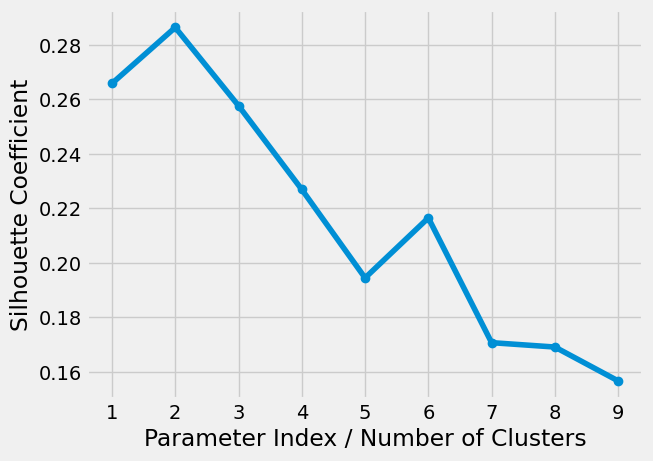

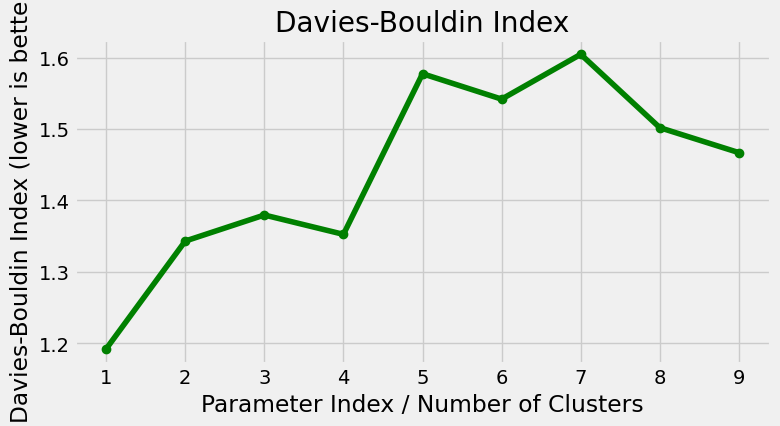

In [350]:
plot_silhouette_score(sil_score_gmm)
plot_db_score(db_score_gmm)

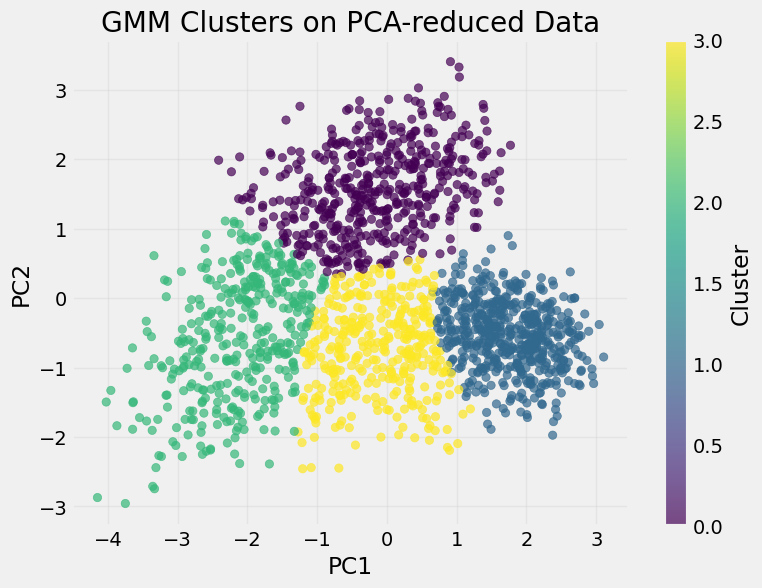

In [355]:

# 2. PCA
pca = PCA(n_components=2)
visualization_df = pca.fit_transform(df_prepped)

# 3. GMM Clustering
# FIX: Use .predict() to get the labels
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(visualization_df)
labels = gmm.predict(visualization_df)  

# 4. Plotting
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    visualization_df[:, 0], 
    visualization_df[:, 1], 
    c=labels,           
    cmap='viridis',     
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters on PCA-reduced Data") # Updated title to match algorithm
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

In [354]:
global_results_df.to_csv("results.csv")